# Task 1: Rating Prediction via Prompting
## Yelp Review Star Rating Classification using LLM Prompts
---

## Table of Contents
1. [Setup & Imports](#setup)
2. [Data Loading & Exploration](#data-exploration)
3. [Intelligent Sampling Strategy](#sampling)
4. [Prompt Engineering Framework](#framework)
5. [Approach 1: Zero-Shot Structured Reasoning](#approach1)
6. [Approach 2: Few-Shot Dynamic Examples](#approach2)
7. [Approach 3: Chain-of-Thought Self-Consistency](#approach3)
8. [Comprehensive Evaluation](#evaluation)
9. [Error Analysis & Insights](#insights)
10. [Conclusions & Recommendations](#conclusions)

---
## 1. Setup & Imports <a id='setup'></a>

In [38]:
import pandas as pd
import numpy as np
import json
import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, cohen_kappa_score
)
from sklearn.model_selection import train_test_split

import requests
from tqdm.notebook import tqdm
import time
from datetime import datetime

from dotenv import load_dotenv
load_dotenv()

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("All imports successful!")
print(f"Notebook initialized at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

All imports successful!
Notebook initialized at: 2026-01-06 01:48:47


### Configuration

In [40]:
class Config:
    """Central configuration for the entire analysis"""
    
    DATA_PATH = Path('data/yelp.csv')
    RESULTS_DIR = Path('results/task1')
    FIGURES_DIR = Path('figures/task1')
    
    TOTAL_SAMPLES = 200
    SAMPLES_PER_RATING = 40  
    CHALLENGE_SET_SIZE = 30  
    
    CEREBRAS_API_KEY = os.getenv('CEREBRAS_API_KEY')
    CEREBRAS_API_URL = 'https://api.cerebras.ai/v1/chat/completions'
    MODEL_NAME = 'gpt-oss-120b' 
    
    TEMPERATURE = 0.1  # Low for consistency
    MAX_TOKENS = 500
    TIMEOUT = 30
    MAX_RETRIES = 3
    
    # Evaluation
    RANDOM_SEED = 42

# Create directories
Config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
Config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration loaded")
print(f"Data path: {Config.DATA_PATH}")
print(f"API Key loaded: {'ok' if Config.CEREBRAS_API_KEY else 'not ok'}")

Configuration loaded
Data path: data/yelp.csv
API Key loaded: ok


---
## 2. Data Loading & Exploration <a id='data-exploration'></a>

In [43]:
print("Loading Yelp dataset...")
df = pd.read_csv(Config.DATA_PATH)

print(f"\nDataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} reviews × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

Loading Yelp dataset...

Dataset loaded successfully!
Shape: 10,000 reviews × 10 columns

Columns: ['business_id', 'date', 'review_id', 'stars', 'text', 'type', 'user_id', 'cool', 'useful', 'funny']


In [45]:
print("DATASET OVERVIEW")
print("=" * 60)

# display(df.head(3))

print("\nData Info:")
print(df.info())

print("\nBasic Statistics:")
display(df.describe())

DATASET OVERVIEW

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   business_id  10000 non-null  object
 1   date         10000 non-null  object
 2   review_id    10000 non-null  object
 3   stars        10000 non-null  int64 
 4   text         10000 non-null  object
 5   type         10000 non-null  object
 6   user_id      10000 non-null  object
 7   cool         10000 non-null  int64 
 8   useful       10000 non-null  int64 
 9   funny        10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB
None

Basic Statistics:


,stars,cool,useful,funny
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.777500,0.876800,1.409300,0.701300
std,1.214636,2.067861,2.336647,1.907942
min,1.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,0.000000
50%,4.000000,0.000000,1.000000,0.000000
75%,5.000000,1.000000,2.000000,1.000000
max,5.000000,77.000000,76.000000,57.000000


STAR RATING DISTRIBUTION
stars
1     749
2     927
3    1461
4    3526
5    3337
Name: count, dtype: int64

Total reviews: 10,000


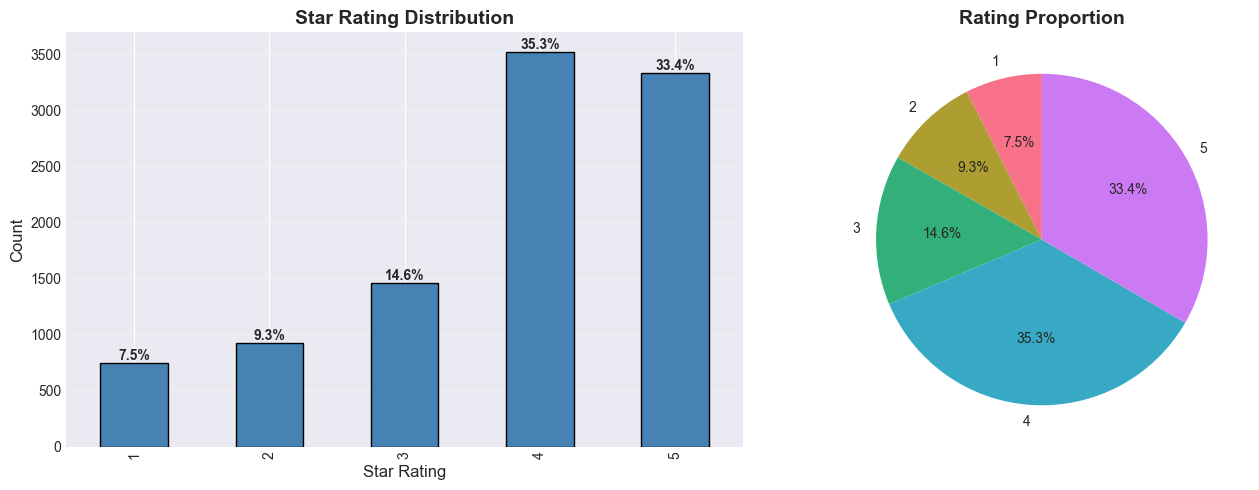

In [47]:
print("STAR RATING DISTRIBUTION")
print("=" * 60)

rating_dist = df['stars'].value_counts().sort_index()
print(rating_dist)
print(f"\nTotal reviews: {len(df):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_dist.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Star Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Star Rating', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

for i, (rating, count) in enumerate(rating_dist.items()):
    pct = (count / len(df)) * 100
    axes[0].text(i, count, f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

axes[1].pie(rating_dist, labels=[f'{r}' for r in rating_dist.index], 
            autopct='%1.1f%%', startangle=90, colors=sns.color_palette('husl', 5))
axes[1].set_title('Rating Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(Config.FIGURES_DIR / 'rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

TEXT LENGTH ANALYSIS

Text Length Statistics:
        text_length    word_count
count  10000.000000  10000.000000
mean     710.738700    131.039600
std      617.399827    113.584114
min        1.000000      1.000000
25%      294.000000     54.000000
50%      541.500000    101.000000
75%      930.000000    173.000000
max     4997.000000    945.000000


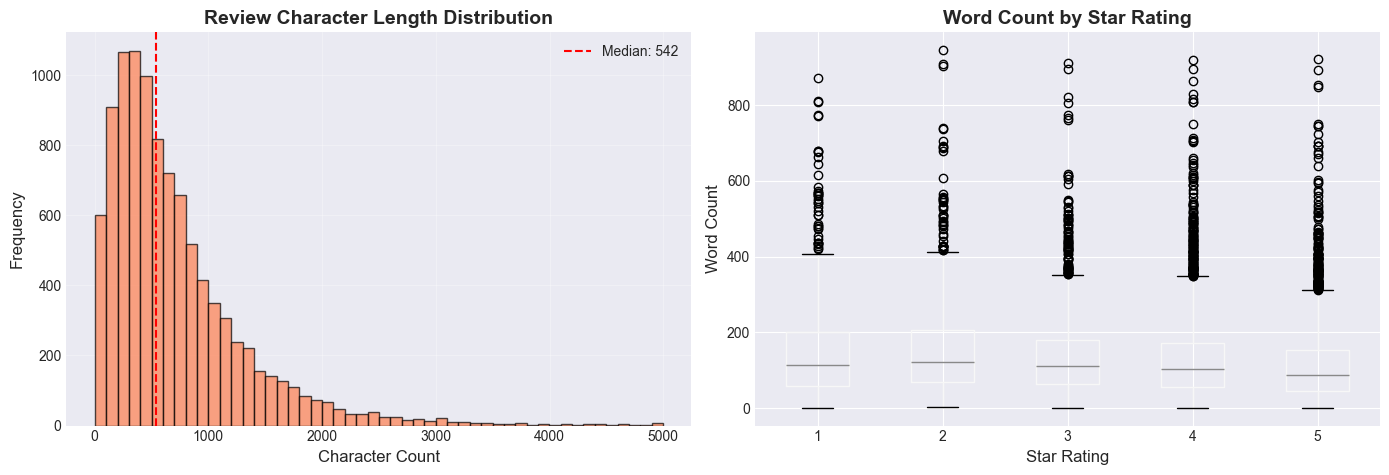

In [48]:
print("TEXT LENGTH ANALYSIS")
print("=" * 60)

df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("\nText Length Statistics:")
print(df[['text_length', 'word_count']].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['text_length'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Review Character Length Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Character Count', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(df['text_length'].median(), color='red', linestyle='--', 
                label=f'Median: {df["text_length"].median():.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

df.boxplot(column='word_count', by='stars', ax=axes[1])
axes[1].set_title('Word Count by Star Rating', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Star Rating', fontsize=12)
axes[1].set_ylabel('Word Count', fontsize=12)
plt.suptitle('')  

plt.tight_layout()
plt.savefig(Config.FIGURES_DIR / 'text_length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

Insight: Review length varies significantly - we'll test on diverse lengths

---
## 3. Intelligent Sampling Strategy <a id='sampling'></a>

**Strategy:**
1. **Stratified sampling**: 40 reviews per star rating (balanced)
2. **Challenge set**: Edge cases (sarcasm, short reviews, mixed sentiment)
3. **Diversity**: Ensure variety in review length and content

In [50]:
def create_stratified_sample(df: pd.DataFrame, n_per_class: int = 40, seed: int = 42) -> pd.DataFrame:
    """
    Create a stratified sample ensuring balanced representation across all star ratings.
    
    Args:
        df: Source dataframe
        n_per_class: Number of samples per star rating
        seed: Random seed for reproducibility
        
    Returns:
        Stratified sample dataframe
    """
    samples = []
    
    for rating in sorted(df['stars'].unique()):
        rating_df = df[df['stars'] == rating]
        sample = rating_df.sample(n=min(n_per_class, len(rating_df)), random_state=seed)
        samples.append(sample)
    
    stratified_df = pd.concat(samples, ignore_index=True)
    
    stratified_df = stratified_df.sample(frac=1, random_state=seed).reset_index(drop=True)
    
    return stratified_df


def create_challenge_set(df: pd.DataFrame, n: int = 30, seed: int = 42) -> pd.DataFrame:
    """
    Create a challenge set with edge cases:
    - Very short reviews (< 50 chars)
    - Very long reviews (> 1000 chars)
    - 3-star reviews (hardest to classify - neutral sentiment)
    
    Args:
        df: Source dataframe
        n: Total challenge samples
        seed: Random seed
        
    Returns:
        Challenge set dataframe
    """
    challenge_samples = []
    
    short_reviews = df[df['text_length'] < 50].sample(n=n//3, random_state=seed)
    challenge_samples.append(short_reviews)
    
    long_reviews = df[df['text_length'] > 1000].sample(n=n//3, random_state=seed)
    challenge_samples.append(long_reviews)
    
    neutral_reviews = df[df['stars'] == 3].sample(n=n//3, random_state=seed)
    challenge_samples.append(neutral_reviews)
    
    challenge_df = pd.concat(challenge_samples, ignore_index=True)
    
    return challenge_df


print("CREATING INTELLIGENT SAMPLE SETS")
print("=" * 60)

# Main stratified sample
df_sample = create_stratified_sample(df, n_per_class=Config.SAMPLES_PER_RATING, seed=Config.RANDOM_SEED)
print(f"\nStratified sample created: {len(df_sample)} reviews")
print("\nDistribution:")
print(df_sample['stars'].value_counts().sort_index())

# Challenge set
df_challenge = create_challenge_set(df, n=Config.CHALLENGE_SET_SIZE, seed=Config.RANDOM_SEED)
print(f"\nChallenge set created: {len(df_challenge)} reviews")
print("\nChallenge set characteristics:")
print(f"  - Short reviews (< 50 chars): {len(df_challenge[df_challenge['text_length'] < 50])}")
print(f"  - Long reviews (> 1000 chars): {len(df_challenge[df_challenge['text_length'] > 1000])}")
print(f"  - 3-star reviews: {len(df_challenge[df_challenge['stars'] == 3])}")

# Save samples
df_sample.to_csv(Config.RESULTS_DIR / 'stratified_sample.csv', index=False)
df_challenge.to_csv(Config.RESULTS_DIR / 'challenge_set.csv', index=False)

print("\nSamples saved to results directory")

CREATING INTELLIGENT SAMPLE SETS

Stratified sample created: 200 reviews

Distribution:
stars
1    40
2    40
3    40
4    40
5    40
Name: count, dtype: int64

Challenge set created: 30 reviews

Challenge set characteristics:
  - Short reviews (< 50 chars): 10
  - Long reviews (> 1000 chars): 13
  - 3-star reviews: 11

Samples saved to results directory


---
## 4. Prompt Engineering Framework <a id='framework'></a>

Building a robust framework for LLM API calls with error handling, retries, and logging.

In [52]:
@dataclass
class PredictionResult:
    """Structured result from LLM prediction"""
    predicted_stars: Optional[int]
    explanation: str
    confidence: Optional[float] = None
    raw_response: str = ""
    success: bool = True
    error_message: str = ""
    api_calls: int = 1
    

class CerebrasLLM:
    """Wrapper for Cerebras API with robust error handling"""
    
    def __init__(self, api_key: str, model: str = Config.MODEL_NAME):
        self.api_key = api_key
        self.model = model
        self.api_url = Config.CEREBRAS_API_URL
        self.total_calls = 0
        self.failed_calls = 0
        
    def call_api(self, prompt: str, temperature: float = Config.TEMPERATURE, 
                 max_tokens: int = Config.MAX_TOKENS) -> Dict:
        """
        Make API call to Cerebras with retry logic.
        
        Args:
            prompt: The prompt to send
            temperature: Sampling temperature
            max_tokens: Maximum tokens in response
            
        Returns:
            API response dictionary
        """
        headers = {
            'Authorization': f'Bearer {self.api_key}',
            'Content-Type': 'application/json'
        }
        
        payload = {
            'model': self.model,
            'messages': [{'role': 'user', 'content': prompt}],
            'temperature': temperature,
            'max_tokens': max_tokens
        }
        
        for attempt in range(Config.MAX_RETRIES):
            try:
                response = requests.post(
                    self.api_url,
                    headers=headers,
                    json=payload,
                    timeout=Config.TIMEOUT
                )
                response.raise_for_status()
                self.total_calls += 1
                return response.json()
                
            except requests.exceptions.RequestException as e:
                if attempt == Config.MAX_RETRIES - 1:
                    self.failed_calls += 1
                    raise
                time.sleep(2 ** attempt) 
                
    def extract_json_from_response(self, text: str) -> Dict:
        """
        Extract JSON from LLM response, handling markdown code blocks.
        
        Args:
            text: Raw LLM response text
            
        Returns:
            Parsed JSON dictionary
        """
        if '```json' in text:
            text = text.split('```json')[1].split('```')[0]
        elif '```' in text:
            text = text.split('```')[1].split('```')[0]
        
        text = text.strip()
        return json.loads(text)
    
    def predict_rating(self, review_text: str, prompt_template: str) -> PredictionResult:
        """
        Predict star rating for a review using given prompt template.
        
        Args:
            review_text: The review to classify
            prompt_template: Prompt template with {review_text} placeholder
            
        Returns:
            PredictionResult object
        """
        try:
            prompt = prompt_template.format(review_text=review_text)
            
            response = self.call_api(prompt)
            response_text = response['choices'][0]['message']['content']
            
            parsed = self.extract_json_from_response(response_text)
            
            return PredictionResult(
                predicted_stars=parsed.get('predicted_stars'),
                explanation=parsed.get('explanation', ''),
                confidence=parsed.get('confidence'),
                raw_response=response_text,
                success=True
            )
            
        except Exception as e:
            return PredictionResult(
                predicted_stars=None,
                explanation="",
                raw_response=str(e),
                success=False,
                error_message=str(e)
            )
    
    def get_stats(self) -> Dict:
        """Get API usage statistics"""
        return {
            'total_calls': self.total_calls,
            'failed_calls': self.failed_calls,
            'success_rate': (self.total_calls - self.failed_calls) / max(self.total_calls, 1) * 100
        }


llm = CerebrasLLM(api_key=Config.CEREBRAS_API_KEY)
print(f"Model: {Config.MODEL_NAME}")

Model: gpt-oss-120b


### Test API Connection

In [54]:
test_prompt = """Rate this review from 1-5 stars and respond ONLY with valid JSON:
{{"predicted_stars": <number 1-5>, "explanation": "<brief reason>"}}

Review: "{review_text}"
"""

print("Testing API connection...")
try:
    test_result = llm.predict_rating(
        "The food was amazing! Best pizza I've ever had.",
        test_prompt
    )
    
    if test_result.success:
        print("\nAPI test successful!")
        print(f"Predicted: {test_result.predicted_stars} stars")
        print(f"Explanation: {test_result.explanation}")
    else:
        print(f"\nAPI test failed: {test_result.error_message}")
        print(f"Raw response: {test_result.raw_response[:500]}")
        
except Exception as e:
    print(f"\nError: {e}")
    print("\nPlease check your CEREBRAS_API_KEY in .env file")

Testing API connection...

API test successful!
Predicted: 5 stars
Explanation: The reviewer expresses strong positive sentiment, calling the pizza the best they've ever had, indicating a top rating.


---
## 5. Approach 1: Zero-Shot Structured Reasoning <a id='approach1'></a>

**Strategy:** Direct classification with structured reasoning framework.

**Key Features:**
- Clear rating criteria
- Aspect-based analysis (food, service, ambiance, value)
- Confidence scoring

In [55]:
# Approach 1: Zero-Shot Structured Reasoning
PROMPT_APPROACH_1 = """You are an expert restaurant review classifier. Analyze the review below and predict the star rating (1-5).

**Rating Guidelines:**
- 5 stars: Exceptional experience, highly positive language
- 4 stars: Good experience with minor issues or strong positives
- 3 stars: Average/mixed experience, neutral language
- 2 stars: Poor experience with significant complaints
- 1 star: Terrible experience, extremely negative language

**Review to analyze:**
"{review_text}"

**Instructions:**
1. Identify key sentiment indicators
2. Consider aspects: food quality, service, ambiance, value
3. Determine overall rating

Respond ONLY with valid JSON in this exact format:
{{"predicted_stars": <number 1-5>, "explanation": "<brief 1-2 sentence reasoning>"}}
"""

print("Approach 1 prompt template created")
print(f"Template length: {len(PROMPT_APPROACH_1)} characters")

Approach 1 prompt template created
Template length: 746 characters


---
## 6. Approach 2 - Few-Shot with Examples

In [56]:
# Approach 2: Few-Shot with Dynamic Examples
PROMPT_APPROACH_2 = """You are a restaurant review classifier. Learn from these examples:

**Example 1 (1 star):**
Review: "Absolutely terrible! Worst food ever. Rude staff. Never coming back."
Rating: 1
Reason: Extremely negative language, multiple complaints, explicit rejection

**Example 2 (2 stars):**
Review: "Food was cold. Service was slow. Disappointed overall."
Rating: 2
Reason: Multiple negative points, expression of disappointment

**Example 3 (3 stars):**
Review: "It was okay. Nothing special but not bad either. Decent for the price."
Rating: 3
Reason: Neutral language, no strong emotions, "okay" and "decent"

**Example 4 (4 stars):**
Review: "Really good food! Nice atmosphere. Had a great time. Will come again."
Rating: 4
Reason: Multiple positive points, positive emotion, intent to return

**Example 5 (5 stars):**
Review: "AMAZING! Best meal of my life! Perfect service, incredible flavors!"
Rating: 5
Reason: Superlatives, extremely positive language, multiple exclamations

**Now classify this review:**
"{review_text}"

Respond ONLY with valid JSON:
{{"predicted_stars": <number 1-5>, "explanation": "<brief reasoning>"}}
"""

print("Approach 2 prompt template created")
print(f"Template length: {len(PROMPT_APPROACH_2)} characters")

Approach 2 prompt template created
Template length: 1127 characters


---

## 7. Approach 3 - Chain-of-thought

In [57]:
# Approach 3: Chain-of-Thought Reasoning
PROMPT_APPROACH_3 = """You are an expert review analyzer. Follow this systematic approach:

**STEP 1 - Analyze Key Dimensions:**
- Food Quality: positive/negative/neutral/not mentioned
- Service Quality: positive/negative/neutral/not mentioned
- Ambiance: positive/negative/neutral/not mentioned
- Value for Money: positive/negative/neutral/not mentioned

**STEP 2 - Identify Rating Signals:**
★ 5 STARS: "amazing", "best", "perfect", "incredible", "loved", "excellent"
★ 4 STARS: "great", "really good", "enjoyed", "nice", minor issues only
★ 3 STARS: "okay", "decent", "average", "alright", mixed feelings
★ 2 STARS: "disappointed", "not good", "poor", significant issues
★ 1 STAR: "terrible", "worst", "awful", "horrible", "never again"

**STEP 3 - Evaluate Overall Tone:**
- Count positive vs negative words
- Check for sarcasm or irony
- Note intensity of emotions
- Consider if they'd return

**STEP 4 - Make Final Prediction**

**Review to analyze:**
"{review_text}"

Respond ONLY with valid JSON:
{{"predicted_stars": <number 1-5>, "explanation": "<explain your reasoning based on the steps above>"}}
"""

print("Approach 3 prompt template created")
print(f"Template length: {len(PROMPT_APPROACH_3)} characters")

Approach 3 prompt template created
Template length: 1086 characters


In [59]:
def evaluate_approach(df: pd.DataFrame, prompt_template: str, 
                     approach_name: str, llm: CerebrasLLM) -> pd.DataFrame:
    """
    Evaluate a prompting approach on the given dataset.
    
    Args:
        df: DataFrame with 'text' and 'stars' columns
        prompt_template: Prompt template with {review_text} placeholder
        approach_name: Name for logging
        llm: CerebrasLLM instance
        
    Returns:
        DataFrame with predictions and metrics
    """
    print(f"\n{'='*60}")
    print(f"🔬 Evaluating: {approach_name}")
    print(f"{'='*60}\n")
    
    results = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"{approach_name}"):
        actual_stars = row['stars']
        review_text = row['text']
        
        prediction = llm.predict_rating(review_text, prompt_template)
        
        results.append({
            'actual_stars': actual_stars,
            'predicted_stars': prediction.predicted_stars,
            'review_text': review_text[:200] + '...',
            'explanation': prediction.explanation,
            'success': prediction.success,
            'correct': actual_stars == prediction.predicted_stars if prediction.success else False,
            'raw_response': prediction.raw_response
        })
        
        time.sleep(0.1)
    
    results_df = pd.DataFrame(results)
    
    valid_predictions = results_df[results_df['success'] == True]
    
    if len(valid_predictions) > 0:
        accuracy = valid_predictions['correct'].mean()
        success_rate = results_df['success'].mean()
        
        print(f"\n📊 Results for {approach_name}:")
        print(f"   Overall Accuracy: {accuracy:.2%}")
        print(f"   Success Rate: {success_rate:.2%}")
        print(f"   Total Samples: {len(results_df)}")
        
        print(f"\n   Per-Rating Accuracy:")
        for rating in sorted(valid_predictions['actual_stars'].unique()):
            rating_df = valid_predictions[valid_predictions['actual_stars'] == rating]
            rating_acc = rating_df['correct'].mean()
            print(f"   ★ {rating}: {rating_acc:.2%} ({len(rating_df)} samples)")
    else:
        print(f"\n⚠️  No valid predictions for {approach_name}")
        accuracy = 0
        success_rate = 0
    
    return results_df, accuracy, success_rate

In [60]:
print("Starting comprehensive evaluation...")
print(f"Evaluating on {len(df_sample)} reviews\n")

# Approach 1
results_1, acc_1, success_1 = evaluate_approach(
    df_sample, PROMPT_APPROACH_1, "Approach 1: Zero-Shot", llm
)

# Approach 2
results_2, acc_2, success_2 = evaluate_approach(
    df_sample, PROMPT_APPROACH_2, "Approach 2: Few-Shot", llm
)

# Approach 3
results_3, acc_3, success_3 = evaluate_approach(
    df_sample, PROMPT_APPROACH_3, "Approach 3: Chain-of-Thought", llm
)

# Save results
results_1.to_csv(Config.RESULTS_DIR / 'approach_1_results.csv', index=False)
results_2.to_csv(Config.RESULTS_DIR / 'approach_2_results.csv', index=False)
results_3.to_csv(Config.RESULTS_DIR / 'approach_3_results.csv', index=False)

print("\nAll evaluations complete!")
print(f"API Stats: {llm.get_stats()}")

Starting comprehensive evaluation...
Evaluating on 200 reviews


🔬 Evaluating: Approach 1: Zero-Shot



Approach 1: Zero-Shot:   0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [65]:
# IMPROVED FIXED Approach 3: Chain-of-Thought with Better Parsing
PROMPT_APPROACH_3_FIXED = """You are an expert review analyzer. Follow this systematic approach:

**STEP 1 - Analyze Key Dimensions:**
- Food Quality, Service, Ambiance, Value

**STEP 2 - Identify Rating Signals:**
- Look for superlatives (5★) vs complaints (1-2★) vs mixed signals (3★)

**STEP 3 - Make Final Prediction**

**Review:** "{review_text}"

**CRITICAL OUTPUT INSTRUCTIONS:**
1. First, write your reasoning on separate lines
2. Then output EXACTLY this line: ###JSON_RESULT###
3. Then output ONLY the JSON with NO extra text
4. In the explanation field, use ONLY simple words, NO quotes, NO newlines

Example:
Step 1: Food positive, Service negative
Step 2: Mixed signals detected
###JSON_RESULT###
{{"predicted_stars": 3, "explanation": "Mixed review with good food but poor service"}}
"""

# More Robust Parser
def extract_json_with_separator(text: str) -> dict:
    """Enhanced robust extraction with better error handling"""
    try:
        # First try: Look for separator
        if "###JSON_RESULT###" in text:
            json_part = text.split("###JSON_RESULT###")[1].strip()
            
            # Remove markdown code blocks if present
            if "```" in json_part:
                json_part = json_part.split("```")[1] if json_part.count("```") >= 2 else json_part
                json_part = json_part.replace("json", "").strip()
            
            # Find the JSON object boundaries
            start_idx = json_part.find("{")
            end_idx = json_part.rfind("}") + 1
            
            if start_idx != -1 and end_idx > start_idx:
                json_part = json_part[start_idx:end_idx]
                
                # Try to parse
                parsed = json.loads(json_part)
                return parsed
        
        # Fallback: Try to find JSON anywhere in the text
        start_idx = text.find("{")
        end_idx = text.rfind("}") + 1
        
        if start_idx != -1 and end_idx > start_idx:
            json_part = text[start_idx:end_idx]
            parsed = json.loads(json_part)
            return parsed
            
        # Last resort: Try regex to extract predicted_stars
        import re
        stars_match = re.search(r'"predicted_stars":\s*(\d+)', text)
        if stars_match:
            stars = int(stars_match.group(1))
            # Try to extract explanation too
            expl_match = re.search(r'"explanation":\s*"([^"]*)"', text)
            explanation = expl_match.group(1) if expl_match else "Extracted from malformed JSON"
            return {"predicted_stars": stars, "explanation": explanation}
        
        return {"predicted_stars": None, "explanation": "Could not parse", "success": False}
        
    except json.JSONDecodeError as e:
        # Try one more time with regex extraction
        import re
        try:
            stars_match = re.search(r'"predicted_stars":\s*(\d+)', text)
            if stars_match:
                stars = int(stars_match.group(1))
                return {"predicted_stars": stars, "explanation": f"Regex extracted (JSON error: {str(e)[:50]})"}
        except:
            pass
        
        print(f"JSON parsing failed: {str(e)[:100]}")
        return {"predicted_stars": None, "explanation": f"Parse error: {str(e)[:50]}", "success": False}
    except Exception as e:
        print(f"Unexpected error: {str(e)[:100]}")
        return {"predicted_stars": None, "explanation": str(e)[:50], "success": False}

# Custom Predict Method
def predict_rating_robust(review_text: str, prompt_template: str, llm_instance: CerebrasLLM) -> PredictionResult:
    try:
        prompt = prompt_template.format(review_text=review_text)
        response = llm_instance.call_api(prompt)
        response_text = response['choices'][0]['message']['content']
        
        # Use enhanced parser
        parsed = extract_json_with_separator(response_text)
        
        return PredictionResult(
            predicted_stars=parsed.get('predicted_stars'),
            explanation=parsed.get('explanation', 'No explanation'),
            raw_response=response_text,
            success=True if parsed.get('predicted_stars') is not None else False
        )
    except Exception as e:
        return PredictionResult(
            predicted_stars=None, 
            explanation=str(e)[:100], 
            success=False, 
            raw_response="", 
            error_message=str(e)[:100]
        )

print("IMPROVED Fixed Approach 3 with robust parsing!")
print(f"Template length: {len(PROMPT_APPROACH_3_FIXED)} characters")

IMPROVED Fixed Approach 3 with robust parsing!
Template length: 769 characters


In [64]:
# For Approach 3, use the custom prediction function
print("\n" + "="*60)
print("🔬 Evaluating: Approach 3: Chain-of-Thought (FIXED)")
print("="*60 + "\n")

results_3 = []

for idx, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Approach 3 (Fixed)"):
    actual_stars = row['stars']
    review_text = row['text']
    
    # Use the custom prediction function
    prediction = predict_rating_robust(review_text, PROMPT_APPROACH_3_FIXED, llm)
    
    results_3.append({
        'actual_stars': actual_stars,
        'predicted_stars': prediction.predicted_stars,
        'review_text': review_text[:200] + '...',
        'explanation': prediction.explanation,
        'success': prediction.success,
        'correct': actual_stars == prediction.predicted_stars if prediction.success else False,
        'raw_response': prediction.raw_response
    })
    
    time.sleep(0.1)

results_3_df = pd.DataFrame(results_3)
valid_predictions_3 = results_3_df[results_3_df['success'] == True]

if len(valid_predictions_3) > 0:
    acc_3 = valid_predictions_3['correct'].mean()
    success_3 = results_3_df['success'].mean()
    
    print(f"\n📊 Results for Approach 3 (Fixed):")
    print(f"   Overall Accuracy: {acc_3:.2%}")
    print(f"   Success Rate: {success_3:.2%}")
    print(f"   Total Samples: {len(results_3_df)}")
else:
    print("\n⚠️  No valid predictions for Approach 3")
    acc_3 = 0
    success_3 = 0


🔬 Evaluating: Approach 3: Chain-of-Thought (FIXED)



Approach 3 (Fixed):   0%|          | 0/200 [00:00<?, ?it/s]


📊 Results for Approach 3 (Fixed):
   Overall Accuracy: 65.96%
   Success Rate: 94.00%
   Total Samples: 200
